# Comparación de modelos de clasificación — Dengue Valle del Cauca 2025

**Grupo 3** · Análisis de Datos I

Este cuaderno continúa el EDA del Taller 2 (`taller2_eda_dengue.ipynb`) y responde: **¿qué modelo de clasificación funciona mejor con los datos SIVIGILA del Valle 2025?**

Planteamos **dos problemas de clasificación**, porque el dataset permite ambos y responden a preguntas distintas del proyecto:

| enfoque A y B| Unidad | Variable objetivo | Pregunta de negocio |
|-------|--------|-------------------|---------------------|
| **A. Hospitalización** | Caso individual (7.441 filas) | `hospitalizado` (PAC_HOS = 1) | Al notificar un caso, ¿podemos anticipar si requerirá hospitalización? → planificar camas |
| **B. Alerta de brote** | Municipio × semana (top 10 municipios) | `alerta` = casos de la **semana siguiente** > P75 del municipio | ¿Podemos anticipar una semana de alta transmisión? → vigilancia |

**Modelos comparados (mismas condiciones):** línea base (Dummy / regla de persistencia), Regresión logística, Naive Bayes, KNN, Árbol de decisión, Random Forest, Gradient Boosting (HistGradientBoosting) y SVM (RBF).

**Métricas:** como las clases están desbalanceadas (26 % hospitalizados; 13 % semanas de alerta) la *accuracy* engaña. Priorizamos **ROC-AUC** (capacidad de ordenar riesgo), **PR-AUC**, **recall** (no dejar pasar casos graves), **F1** y **accuracy balanceada**.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import (StratifiedKFold, GroupKFold, cross_validate,
                                     train_test_split, GridSearchCV)
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score,
                             precision_score, balanced_accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             precision_recall_curve)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import DATA_PROCESSED

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42

df = pd.read_parquet(DATA_PROCESSED / "dengue_sivigila_2025_valle_limpio.parquet")
print(f"Casos Valle 2025: {len(df):,} × {df.shape[1]} columnas")
print(f"% hospitalizados: {df['hospitalizado'].mean()*100:.1f}%")

Casos Valle 2025: 7,441 × 71 columnas
% hospitalizados: 26.5%


---
# 1. enfoque A — Clasificar si un caso será hospitalizado

## 1.1. Selección de variables y control de fuga de información (*data leakage*)

Solo usamos información **disponible al momento de la consulta/notificación**. Se excluyen variables que "revelan" la respuesta o se conocen después:

| Excluida | Motivo |
|----------|--------|
| `PAC_HOS`, `FEC_HOS` | Son la variable objetivo (FEC_HOS solo existe si hubo hospitalización) |
| `confirmados`, `TIP_CAS`, `Estado_final_de_caso`, `nom_est_f_caso`, `AJUSTE` | Resultado de laboratorio / ajustes posteriores |
| `Nombre_upgd`, `COD_PRE` | Institución que notifica: una clínica de alta complejidad casi siempre hospitaliza. Se evalúa aparte (§1.6) |

**Variables predictoras (features):**

- Numéricas: `edad_anios`, `SEMANA`, `dias_sint_consulta` (días entre inicio de síntomas y consulta — **nueva**).
- Categóricas: `SEXO`, `AREA`, `TIP_SS` (régimen de salud), `PER_ETN`, `estrato`, `municipio` (top 10 + OTRO).
- Binarias: grupos poblacionales `GP_*` (gestante, migrante, desplazado, discapacidad…), `residente_fuera` (vive fuera del municipio de ocurrencia).

In [2]:
d = df.copy()
d["dias_sint_consulta"] = (d["FEC_CON"] - d["INI_SIN"]).dt.days.clip(0, 30)
d["estrato"] = d["estrato"].astype(str).str.strip()
d["residente_fuera"] = ((d["COD_MUN_R"] != d["COD_MUN_O"]) | (d["COD_DPTO_R"] != 76)).astype(int)
top10_mun = d["Municipio_ocurrencia"].value_counts().head(10).index
d["municipio"] = d["Municipio_ocurrencia"].astype(str).where(d["Municipio_ocurrencia"].isin(top10_mun), "OTRO")

GP = ["GP_DISCAPA", "GP_DESPLAZ", "GP_MIGRANT", "GP_GESTAN", "GP_VIC_VIO", "GP_OTROS"]
for g in GP:
    d[g] = (d[g] == 1).astype(int)   # SIVIGILA: 1 = Sí, 2 = No

NUM = ["edad_anios", "SEMANA", "dias_sint_consulta"]
CAT = ["SEXO", "AREA", "TIP_SS", "PER_ETN", "estrato", "municipio"]
BIN = GP + ["residente_fuera"]

X = d[NUM + CAT + BIN]
y = d["hospitalizado"].astype(int)

def preprocesador(cat=CAT):
    return ColumnTransformer([
        ("num", StandardScaler(), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False), cat),
        ("bin", "passthrough", BIN),
    ])

print("Features:", X.shape[1], "| Filas:", len(X))
print("Balance de clases:\n", y.value_counts(normalize=True).round(3))
d.groupby(pd.cut(d["dias_sint_consulta"], [-1, 1, 3, 5, 30]))["hospitalizado"].mean().round(3).rename("% hosp. por días síntomas→consulta")

Features: 16 | Filas: 7441
Balance de clases:
 hospitalizado
0    0.735
1    0.265
Name: proportion, dtype: float64


dias_sint_consulta
(-1, 1]    0.207
(1, 3]     0.232
(3, 5]     0.307
(5, 30]    0.335
Name: % hosp. por días síntomas→consulta, dtype: float64

## 1.2. Partición entrenamiento / prueba

Se reserva un **20 % estratificado** como conjunto de prueba final (nunca visto al comparar modelos). La comparación se hace con **validación cruzada estratificada de 5 pliegues** sobre el 80 % restante.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | % hosp train {y_train.mean():.3f} / test {y_test.mean():.3f}")

Train: 5,952 | Test: 1,489 | % hosp train 0.265 / test 0.265


## 1.3. Comparación de 8 modelos (validación cruzada 5-fold)

Todos los modelos usan `class_weight="balanced"` cuando lo soportan, para no ignorar la clase minoritaria (hospitalizados).

In [4]:
MODELOS = {
    "Dummy (línea base)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Naive Bayes": GaussianNB(),
    "KNN (k=25)": KNeighborsClassifier(n_neighbors=25),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=6, min_samples_leaf=30, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=400, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, class_weight="balanced", random_state=SEED),
    "SVM (RBF)": SVC(C=1, class_weight="balanced", probability=True, random_state=SEED),
}
SCORING = {"ROC-AUC": "roc_auc", "PR-AUC": "average_precision", "F1": "f1", "Recall": "recall",
           "Precisión": "precision", "Acc. balanceada": "balanced_accuracy", "Accuracy": "accuracy"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

filas = []
for nombre, modelo in MODELOS.items():
    r = cross_validate(Pipeline([("pre", preprocesador()), ("modelo", modelo)]),
                       X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    fila = {"Modelo": nombre, **{k: r[f"test_{k}"].mean() for k in SCORING}}
    fila["ROC-AUC (±sd)"] = r["test_ROC-AUC"].std()
    fila["Tiempo (s)"] = r["fit_time"].mean()
    filas.append(fila)

resultados_A = pd.DataFrame(filas).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
resultados_A.style.format(precision=3).background_gradient(subset=["ROC-AUC", "PR-AUC", "F1", "Recall", "Acc. balanceada"], cmap="Greens")

,Modelo,ROC-AUC,PR-AUC,F1,Recall,Precisión,Acc. balanceada,Accuracy,ROC-AUC (±sd),Tiempo (s)
0,Random Forest,0.737,0.510,0.515,0.606,0.449,0.669,0.698,0.014,0.493
1,SVM (RBF),0.729,0.492,0.513,0.628,0.434,0.666,0.684,0.015,2.622
2,Gradient Boosting,0.718,0.483,0.495,0.567,0.439,0.653,0.694,0.016,0.570
3,KNN (k=25),0.700,0.458,0.300,0.199,0.610,0.576,0.754,0.013,0.043
4,Regresión logística,0.697,0.440,0.482,0.663,0.379,0.635,0.622,0.009,0.042
5,Árbol de decisión,0.694,0.465,0.482,0.539,0.438,0.643,0.692,0.013,0.041
6,Naive Bayes,0.679,0.398,0.444,0.549,0.399,0.612,0.642,0.009,0.035
7,Dummy (línea base),0.500,0.265,0.000,0.000,0.000,0.500,0.735,0.000,0.032


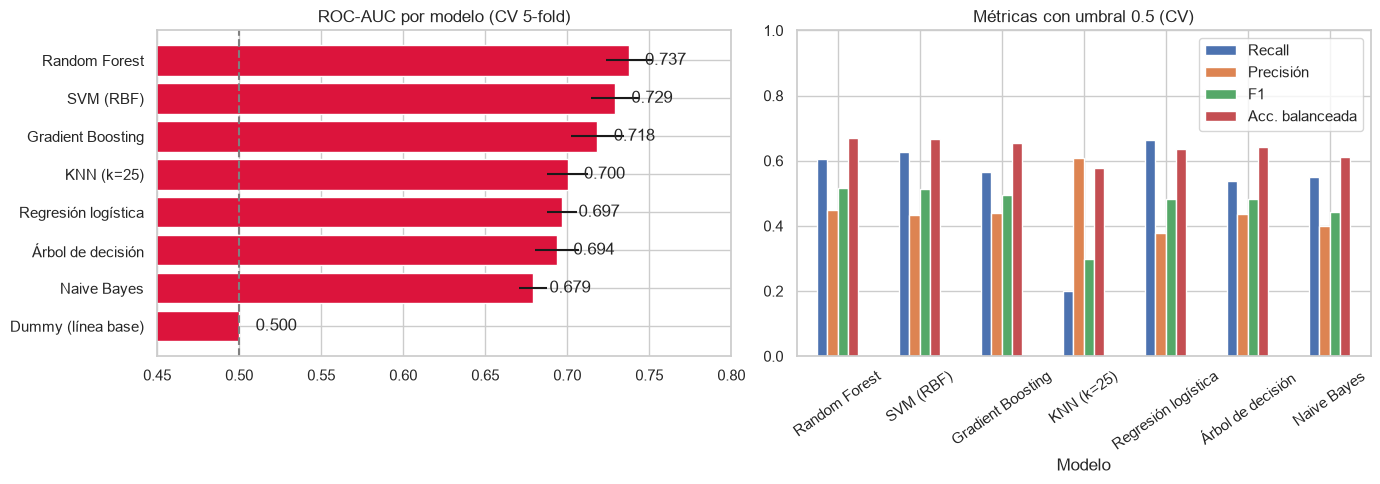

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = resultados_A.sort_values("ROC-AUC")
axes[0].barh(orden["Modelo"], orden["ROC-AUC"], xerr=orden["ROC-AUC (±sd)"], color="crimson")
axes[0].axvline(0.5, ls="--", c="gray"); axes[0].set_xlim(0.45, 0.8)
axes[0].set_title("ROC-AUC por modelo (CV 5-fold)")
for i, v in enumerate(orden["ROC-AUC"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

m = resultados_A.set_index("Modelo")[["Recall", "Precisión", "F1", "Acc. balanceada"]].drop("Dummy (línea base)")
m.plot(kind="bar", ax=axes[1], rot=35)
axes[1].set_title("Métricas con umbral 0.5 (CV)"); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Lectura:**

- Todos los modelos superan a la línea base (AUC 0.50), así que **sí hay señal** en las variables.
- Los **modelos de ensamble** (Random Forest, Gradient Boosting) y SVM quedan arriba en ROC-AUC y PR-AUC; captan interacciones no lineales (p. ej. edad × municipio) que la regresión logística no ve.
- **KNN** tiene la accuracy más alta pero recall muy bajo: casi siempre predice "no hospitalizado". Es el ejemplo de por qué la accuracy engaña con clases desbalanceadas.
- **Naive Bayes** y el **Árbol** simple quedan por debajo: el primero asume independencia de variables y el segundo es demasiado rígido.

## 1.4. Ajuste de hiperparámetros del mejor modelo

Afinamos **Random Forest** (mejor ROC-AUC y el más estable entre pliegues) con una búsqueda en malla pequeña, optimizando ROC-AUC.

In [6]:
pipe_rf = Pipeline([("pre", preprocesador()),
                    ("modelo", RandomForestClassifier(n_estimators=400, class_weight="balanced", n_jobs=-1, random_state=SEED))])
grid = GridSearchCV(pipe_rf, {
    "modelo__min_samples_leaf": [3, 5, 10, 20],
    "modelo__max_features": ["sqrt", 0.3, 0.5],
    "modelo__max_depth": [None, 12],
}, scoring="roc_auc", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("Mejores hiperparámetros:", grid.best_params_)
print(f"ROC-AUC CV afinado: {grid.best_score_:.3f}")
mejor_A = grid.best_estimator_

Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 3}
ROC-AUC CV afinado: 0.741


## 1.5. Evaluación final en el conjunto de prueba (20 % no visto)

El umbral por defecto (0.5) no es necesariamente el mejor. Para una alerta hospitalaria preferimos **no perder casos graves** (recall alto), así que elegimos el umbral que maximiza F1 **sobre entrenamiento** (validación cruzada) y lo aplicamos en prueba.

Umbral elegido (máx. F1 en CV de train): 0.496


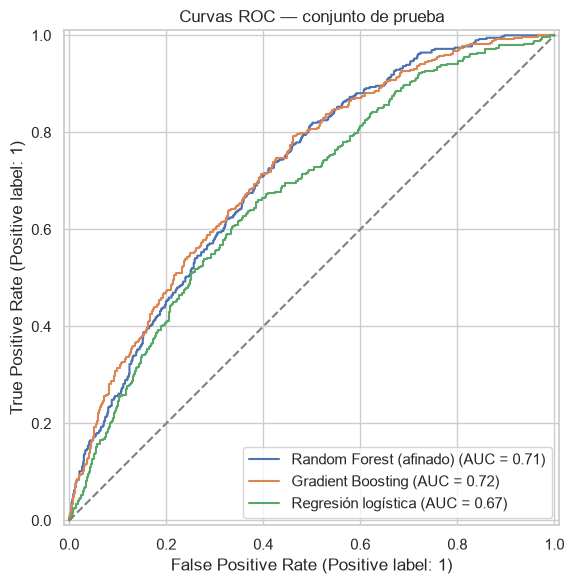

,Modelo,ROC-AUC,PR-AUC
0,Random Forest (afinado),0.715,0.455
1,Gradient Boosting,0.719,0.466
2,Regresión logística,0.675,0.399


In [ ]:
from sklearn.model_selection import cross_val_predict
p_oof = cross_val_predict(mejor_A, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, p_oof)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
umbral_A = float(thr[np.argmax(f1s[:-1])])
print(f"Umbral elegido (máx. F1 en CV de train): {umbral_A:.3f}")

# Top 3 modelos reentrenados en todo train y evaluados en test
finalistas = {
    "Random Forest (afinado)": mejor_A,
    "Gradient Boosting": Pipeline([("pre", preprocesador()), ("modelo", MODELOS["Gradient Boosting"])]).fit(X_train, y_train),
    "Regresión logística": Pipeline([("pre", preprocesador()), ("modelo", MODELOS["Regresión logística"])]).fit(X_train, y_train),
}
fig, ax = plt.subplots(figsize=(6.5, 6))
filas = []
for nombre, mod in finalistas.items():
    p = mod.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, p, name=nombre, ax=ax)
    filas.append({"Modelo": nombre, "ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p)})
ax.plot([0, 1], [0, 1], "--", c="gray"); ax.set_title("Curvas ROC — conjunto de prueba")
plt.tight_layout(); plt.show()
pd.DataFrame(filas).round(3)

                  precision    recall  f1-score   support

No hospitalizado      0.817     0.732     0.772      1095
   Hospitalizado      0.422     0.546     0.476       394

        accuracy                          0.682      1489
       macro avg      0.620     0.639     0.624      1489
    weighted avg      0.713     0.682     0.694      1489

Accuracy balanceada: 0.639


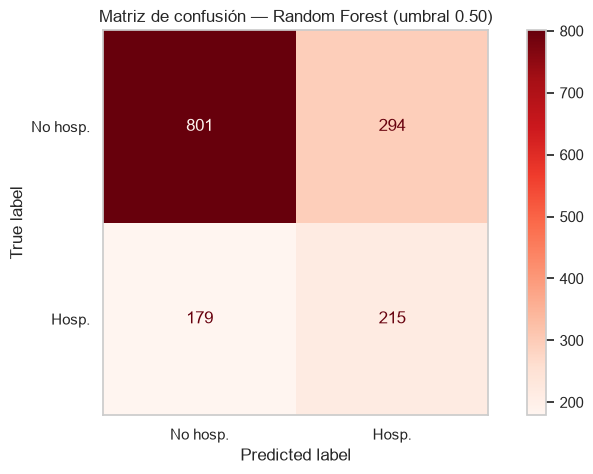

In [8]:
p_test = mejor_A.predict_proba(X_test)[:, 1]
yhat = (p_test >= umbral_A).astype(int)
print(classification_report(y_test, yhat, target_names=["No hospitalizado", "Hospitalizado"], digits=3))
print(f"Accuracy balanceada: {balanced_accuracy_score(y_test, yhat):.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_test, yhat), display_labels=["No hosp.", "Hosp."]).plot(cmap="Reds")
plt.title(f"Matriz de confusión — Random Forest (umbral {umbral_A:.2f})"); plt.grid(False); plt.show()

### ¿Qué variables usa el modelo? (importancia por permutación)

Mide cuánto cae el ROC-AUC en prueba si "desordenamos" cada variable. Es más confiable que la importancia interna del Random Forest.

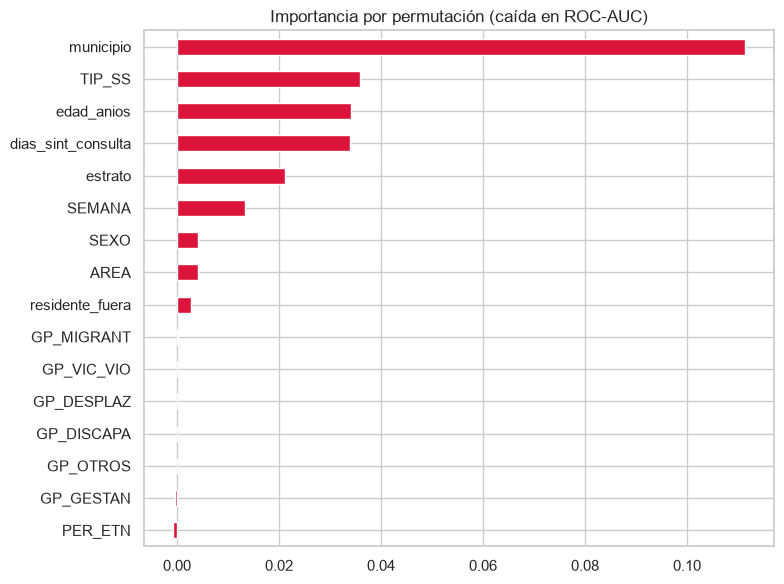

municipio             0.1114
TIP_SS                0.0359
edad_anios            0.0341
dias_sint_consulta    0.0340
estrato               0.0213
SEMANA                0.0133
SEXO                  0.0042
AREA                  0.0042
dtype: float64

In [9]:
imp = permutation_importance(mejor_A, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=SEED, n_jobs=-1)
imp_df = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()
imp_df.plot(kind="barh", color="crimson", figsize=(8, 6), title="Importancia por permutación (caída en ROC-AUC)")
plt.tight_layout(); plt.show()
imp_df.sort_values(ascending=False).round(4).head(8)

## 1.6. Análisis de sensibilidad: ¿y si agregamos la institución que notifica (UPGD)?

`Nombre_upgd` se conoce al notificar, pero refleja **dónde** se atiende al paciente (clínica de alta complejidad vs. puesto de salud), no su riesgo clínico. Lo probamos aparte para mostrar el efecto.

In [10]:
X_upgd = d[NUM + CAT + BIN + ["Nombre_upgd"]].copy()
X_upgd["Nombre_upgd"] = X_upgd["Nombre_upgd"].astype(str)
Xu_train, Xu_test = X_upgd.loc[X_train.index], X_upgd.loc[X_test.index]
filas = []
for nombre in ["Regresión logística", "Random Forest", "Gradient Boosting"]:
    for con in [False, True]:
        pipe = Pipeline([("pre", preprocesador(CAT + ["Nombre_upgd"] if con else CAT)), ("modelo", MODELOS[nombre])])
        r = cross_validate(pipe, Xu_train if con else X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "recall"], n_jobs=-1)
        filas.append({"Modelo": nombre, "Con UPGD": con, "ROC-AUC": r["test_roc_auc"].mean(),
                      "F1": r["test_f1"].mean(), "Recall": r["test_recall"].mean()})
pd.DataFrame(filas).pivot(index="Modelo", columns="Con UPGD", values=["ROC-AUC", "F1"]).round(3)

ROC-AUC            F1       
Con UPGD              False  True   False  True 
Modelo                                          
Gradient Boosting     0.718  0.872  0.495  0.655
Random Forest         0.737  0.877  0.515  0.663
Regresión logística   0.697  0.880  0.482  0.661

**Lectura:** con la institución el ROC-AUC sube de ≈0.73 a ≈0.88 y las diferencias entre modelos casi desaparecen (incluso la regresión logística alcanza a los ensambles). Esto indica que gran parte de la "predicción" viene del **tipo de institución**, no del paciente. Es útil para planificar camas **por institución**, pero no para identificar pacientes de riesgo; por eso el modelo principal **no** la incluye.

---
# 2. enfoque B — Alerta temprana de brote (municipio × semana)

Construimos un panel semanal para los **10 municipios con más casos** (82 % del Valle). Para cada municipio-semana *t*:

- **Predictoras** (solo pasado): casos de la semana *t* y rezagos *t-1…t-3*, medias móviles de 4 y 8 semanas, tendencia, hospitalizados de la semana previa, estacionalidad (seno/coseno de la semana) y el umbral del municipio.
- **Objetivo:** `alerta = 1` si los casos de la **semana t+1** superan el percentil 75 semanal del municipio (mínimo 3 casos).
- **Línea base:** regla de *persistencia* ("si esta semana ya está sobre el umbral, la próxima también").

In [11]:
d["mun"] = d["Municipio_ocurrencia"].astype(str)
panel = d[d["mun"].isin(top10_mun)].groupby(["mun", "SEMANA"]).agg(
    casos=("CONSECUTIVE", "count"), hosp=("hospitalizado", "sum")).reset_index()
idx = pd.MultiIndex.from_product([top10_mun.astype(str), range(1, 54)], names=["mun", "SEMANA"])
panel = panel.set_index(["mun", "SEMANA"]).reindex(idx, fill_value=0).reset_index().sort_values(["mun", "SEMANA"])

g = panel.groupby("mun")["casos"]
for l in [1, 2, 3, 4]:
    panel[f"lag{l}"] = g.shift(l)
panel["media4"] = g.transform(lambda s: s.shift(1).rolling(4).mean())
panel["media8"] = g.transform(lambda s: s.shift(1).rolling(8).mean())
panel["tendencia"] = panel["lag1"] - panel["lag4"]
panel["hosp_lag1"] = panel.groupby("mun")["hosp"].shift(1)
panel["sem_sin"] = np.sin(2 * np.pi * panel["SEMANA"] / 52)
panel["sem_cos"] = np.cos(2 * np.pi * panel["SEMANA"] / 52)
panel["umbral"] = panel.groupby("mun")["casos"].transform(lambda s: s.quantile(0.75)).clip(lower=3)
panel["casos_next"] = g.shift(-1)
panel["alerta"] = (panel["casos_next"] > panel["umbral"]).astype(int)
panel["alerta_hoy"] = (panel["casos"] > panel["umbral"]).astype(int)

pb = panel.dropna(subset=["lag4", "media8", "casos_next"]).reset_index(drop=True)
FEATS_B = ["casos", "lag1", "lag2", "lag3", "media4", "media8", "tendencia", "hosp_lag1", "sem_sin", "sem_cos", "umbral"]
print(f"Filas del panel: {len(pb)} | semanas de alerta: {pb['alerta'].sum()} ({pb['alerta'].mean()*100:.1f}%)")
pb.groupby(pd.cut(pb["SEMANA"], [0, 13, 26, 39, 53], labels=["S1-13", "S14-26", "S27-39", "S40-53"]), observed=False)["alerta"].agg(["sum", "mean"]).round(3)

Filas del panel: 440 | semanas de alerta: 57 (13.0%)


,sum,mean
SEMANA,,
S1-13,26,0.520
S14-26,20,0.154
S27-39,5,0.038
S40-53,6,0.046


Evaluamos con **dos esquemas de validación**:

1. **Por municipio (GroupKFold):** entrena con unos municipios y prueba en otros → ¿el patrón se generaliza a municipios no vistos?
2. **Temporal:** entrena con semanas pasadas y prueba en semanas futuras → es el escenario **real** de una alerta temprana.

In [ ]:
MODELOS_B = {
    "Persistencia (regla)": None,
    "Regresión logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "KNN (k=15)": make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(300, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "Gradient Boosting": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_depth=3, class_weight="balanced", random_state=SEED),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(class_weight="balanced", probability=True, random_state=SEED)),
}

def evaluar_b(splits):
    filas = []
    for nombre, modelo in MODELOS_B.items():
        res = []
        for tr, te in splits:
            tr, te = pb.loc[tr], pb.loc[te]
            if te["alerta"].nunique() < 2:
                continue
            if modelo is None:
                p = te["alerta_hoy"].to_numpy(float)
            else:
                modelo.fit(tr[FEATS_B], tr["alerta"]); p = modelo.predict_proba(te[FEATS_B])[:, 1]
            yh = (p >= 0.5).astype(int)
            res.append([roc_auc_score(te["alerta"], p), average_precision_score(te["alerta"], p),
                        f1_score(te["alerta"], yh), recall_score(te["alerta"], yh),
                        precision_score(te["alerta"], yh, zero_division=0), balanced_accuracy_score(te["alerta"], yh)])
        filas.append([nombre, *np.mean(res, axis=0)])
    return (pd.DataFrame(filas, columns=["Modelo", "ROC-AUC", "PR-AUC", "F1", "Recall", "Precisión", "Acc. balanceada"])
              .sort_values("ROC-AUC", ascending=False).reset_index(drop=True))

split_mun = [(pb.index[a], pb.index[b]) for a, b in GroupKFold(5).split(pb, groups=pb["mun"])]
semanas = np.array(sorted(pb["SEMANA"].unique())); bloques = np.array_split(semanas, 5)
split_tmp = [(pb.index[pb["SEMANA"].isin(np.concatenate(bloques[:i]))], pb.index[pb["SEMANA"].isin(bloques[i])]) for i in range(2, 5)]

res_B_mun = evaluar_b(split_mun)
res_B_tmp = evaluar_b(split_tmp)
print("=== Validación por municipio (GroupKFold) ===")
display(res_B_mun.style.format(precision=3).background_gradient(subset=["ROC-AUC", "F1"], cmap="Greens"))
print("=== Validación temporal (pasado → futuro) ===")
display(res_B_tmp.style.format(precision=3).background_gradient(subset=["ROC-AUC", "F1"], cmap="Greens"))

=== Validación por municipio (GroupKFold) ===


,Modelo,ROC-AUC,PR-AUC,F1,Recall,Precisión,Acc. balanceada
0,Gradient Boosting,0.800,0.444,0.358,0.493,0.304,0.675
1,Random Forest,0.798,0.437,0.418,0.645,0.333,0.721
2,Regresión logística,0.791,0.452,0.421,0.701,0.301,0.732
3,Naive Bayes,0.769,0.418,0.139,0.213,0.178,0.557
4,Árbol de decisión,0.766,0.359,0.398,0.712,0.282,0.713
5,KNN (k=15),0.753,0.339,0.060,0.034,0.300,0.515
6,SVM (RBF),0.737,0.314,0.000,0.000,0.000,0.500
7,Persistencia (regla),0.625,0.204,0.338,0.363,0.318,0.625


=== Validación temporal (pasado → futuro) ===


,Modelo,ROC-AUC,PR-AUC,F1,Recall,Precisión,Acc. balanceada
0,Regresión logística,0.793,0.295,0.051,0.083,0.037,0.524
1,Gradient Boosting,0.743,0.143,0.111,0.167,0.083,0.568
2,Random Forest,0.737,0.135,0.000,0.000,0.000,0.493
3,Naive Bayes,0.627,0.088,0.000,0.000,0.000,0.500
4,SVM (RBF),0.611,0.109,0.000,0.000,0.000,0.500
5,Persistencia (regla),0.606,0.218,0.296,0.250,0.400,0.606
6,Árbol de decisión,0.517,0.049,0.053,0.500,0.029,0.549
7,KNN (k=15),0.484,0.044,0.000,0.000,0.000,0.500


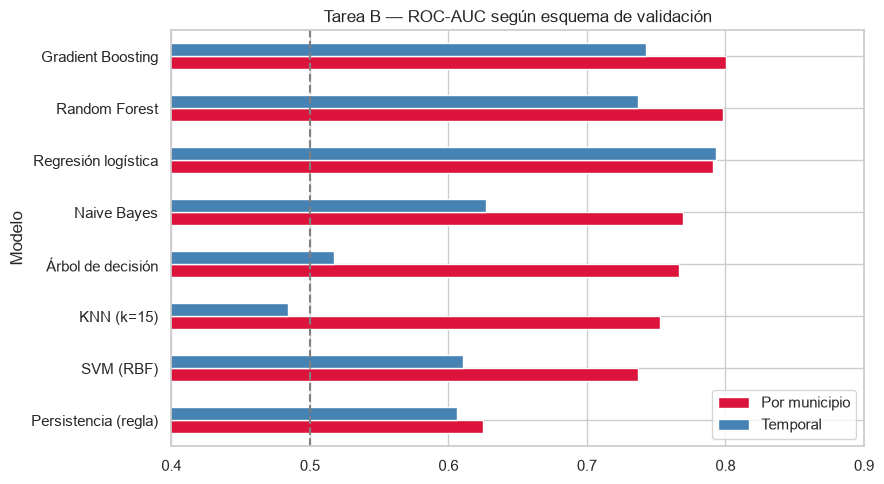

In [13]:
comp = res_B_mun.set_index("Modelo")[["ROC-AUC"]].rename(columns={"ROC-AUC": "Por municipio"}).join(
       res_B_tmp.set_index("Modelo")[["ROC-AUC"]].rename(columns={"ROC-AUC": "Temporal"}))
comp.sort_values("Por municipio").plot(kind="barh", figsize=(9, 5), color=["crimson", "steelblue"])
plt.axvline(0.5, ls="--", c="gray"); plt.xlim(0.4, 0.9)
plt.title("Tarea B — ROC-AUC según esquema de validación"); plt.tight_layout(); plt.show()

**Lectura enfoque B:**

- **Por municipio**, Gradient Boosting, Random Forest y Regresión logística quedan muy parejos (ROC-AUC ≈ 0.80) y todos superan la regla de persistencia (≈ 0.63). La **regresión logística** logra el mejor recall/F1 y es la más interpretable.
- **En validación temporal** (el caso real) el ordenamiento de riesgo se mantiene aceptable para la logística (AUC ≈ 0.79), pero **con umbral 0.5 casi ningún modelo detecta alertas** (F1 ≈ 0–0.1). La regla de persistencia, con F1 ≈ 0.30, es mejor en la práctica.
- La causa es estructural: en 2025 el brote ocurre **al inicio del año** (52 % de las semanas S1-13 son alerta vs. 4 % en S27-39). Con un solo año, el modelo aprende el pico y luego lo prueba en semanas donde casi no hay alertas. **Hacen falta varios años (2019-2025, ya disponibles en el Drive del grupo) y variables climáticas (IDEAM)** para un sistema de alerta confiable.

---
# 3. Conclusiones y recomendación

## 3.1. Resumen de resultados

In [14]:
resumen = pd.DataFrame([
    {"Tarea": "A. Hospitalización (caso)", "Mejor modelo": "Random Forest (afinado)",
     "ROC-AUC CV": round(grid.best_score_, 3), "ROC-AUC prueba": round(roc_auc_score(y_test, p_test), 3),
     "Recall prueba": round(recall_score(y_test, yhat), 3), "F1 prueba": round(f1_score(y_test, yhat), 3),
     "Alternativa": "Gradient Boosting (casi igual); Regresión logística si se prioriza interpretabilidad"},
    {"Tarea": "B. Alerta de brote (mun×semana)", "Mejor modelo": "Regresión logística",
     "ROC-AUC CV": round(res_B_mun.set_index("Modelo").loc["Regresión logística", "ROC-AUC"], 3),
     "ROC-AUC prueba": round(res_B_tmp.set_index("Modelo").loc["Regresión logística", "ROC-AUC"], 3),
     "Recall prueba": round(res_B_tmp.set_index("Modelo").loc["Regresión logística", "Recall"], 3),
     "F1 prueba": round(res_B_tmp.set_index("Modelo").loc["Regresión logística", "F1"], 3),
     "Alternativa": "Gradient Boosting; aún no supera en la práctica a la regla de persistencia"},
])
resumen

,Tarea,Mejor modelo,ROC-AUC CV,ROC-AUC prueba,Recall prueba,F1 prueba,Alternativa
0,A. Hospitalización (caso),Random Forest (afinado),0.741,0.715,0.546,0.476,Gradient Boosting (casi igual); Regresión logí...
1,B. Alerta de brote (mun×semana),Regresión logística,0.791,0.793,0.083,0.051,Gradient Boosting; aún no supera en la práctic...


## 3.2. ¿Qué modelo clasifica mejor?

**Tarea A — Hospitalización: Random Forest es el mejor clasificador.**

1. Tiene el **mayor ROC-AUC en validación cruzada** (0.737; 0.741 afinado) y el mayor PR-AUC y F1 de los 8 modelos. En el 20 % de prueba obtiene 0.715, empatado con Gradient Boosting (0.719): la diferencia entre ambos está dentro del ruido (±0.015).
2. En prueba detecta **algo más de la mitad de las hospitalizaciones** (recall 0.55, precisión 0.42), frente a 0 de la línea base.
3. Gradient Boosting queda prácticamente empatado; SVM también es competitivo pero es más lento y menos interpretable.
4. Las variables que más pesan son **municipio** (Cali y Cartago hospitalizan mucho más que Jamundí o Tuluá), **régimen de salud**, **edad** (niños y adultos mayores se hospitalizan más, como vimos en H3 del EDA) y **días entre síntomas y consulta** (quien consulta tarde se hospitaliza más).

**Tarea B — Alerta de brote:** la **Regresión logística** ordena mejor el riesgo en el escenario temporal, pero con un solo año **ningún modelo es confiable todavía** para emitir alertas; hoy la regla de persistencia funciona igual o mejor.

## 3.3. Limitaciones

- **ROC-AUC ≈ 0.72–0.74** indica capacidad predictiva **moderada**: SIVIGILA no trae variables clínicas (signos de alarma, plaquetas, comorbilidades), que son las que más predicen la hospitalización en la literatura (Delpino et al., 2026).
- La meta SMART de **precisión > 80 %** del proyecto **no se alcanza** con estas variables: la precisión en la clase hospitalizado es ≈ 0.42.
- Un solo año (2025) y un solo departamento: la Tarea B tiene solo ~57 semanas de alerta.
- Los hiperparámetros se afinaron solo para Random Forest.

## 3.4. Próximos pasos

1. Integrar los años **2019–2025** para la Tarea B (más brotes para aprender y validación año a año).
2. Agregar **clima (IDEAM: lluvia, temperatura)** con rezagos de 2–6 semanas y **población (DANE)** para tasas por 100 mil habitantes.
3. Si se consiguen variables clínicas (clasificación con/sin signos de alarma), reentrenar la Tarea A.
4. Calibrar probabilidades y elegir el umbral junto con el área de salud según el costo de un falso negativo.